# Demanda intradía y despacho precalculado — ATU resolver

**Cuaderno de exploración (no toca el motor de producción).** Importa las funciones reales de
`engine/` y mide una propuesta antes de comprometerla.

## El problema
En horas pico, los pasajeros hacen cola 1–2 h en algunas estaciones mientras buses de otras
rutas viajan casi vacíos. Hoy el sistema **no reparte buses por hora pico** porque `Mbase` es una
matriz OD **promedio diaria** (indexada solo por tipo de día) y el bucle online la prorratea
**uniformemente** sobre el día (`baseline.escalar_a_ventana`: `ventana/1440`). Eso aplana los picos.

## La propuesta (lo que este cuaderno valida)
1. **Perfiles de demanda por hora**: `Mbase[tipo_día][hora]` (tensor `24×N×N`).
2. **Tabla de despacho precalculada** ("el entrenamiento"): resolver el MILP **offline** una vez
   por `(tipo_día, hora)`; en runtime el caso base es un *lookup O(1)* del plan pico-consciente.
3. **Objetivo minimax**: minimizar la **peor cola** por servicio en vez de solo la suma de demanda
   no servida.

In [1]:
import sys, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolver la raíz del repo para importar engine/ aunque el cuaderno viva en notebooks/.
ROOT = Path.cwd()
while not (ROOT / "engine").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from engine.data_loader import cargar_eventos_csv
from engine.trip_chaining.chaining import reconstruir_od
from engine.demand import baseline
from engine.network import topology
from engine.optimizer import milp
from ortools.linear_solver import pywraplp

N = topology.N_ESTACIONES
print("Raíz del repo:", ROOT)
print("Estaciones:", N, "| Servicios:", [s.codigo for s in topology.SERVICIOS])

Raíz del repo: /home/ivettmera/Documents/UNI/SEM 26-1/6_DS/Proyecto/ATU-solver
Estaciones: 45 | Servicios: ['REG', 'EXP_A', 'EXP_B']


## 1. Carga y reconstrucción de la OD (pipeline de producción)

Un CSV = un día. Se carga cada día por separado (para **no encadenar viajes entre días**) y se
reconstruye su OD con el mismo `reconstruir_od` que corre en el servicio.

In [2]:
DATA_DIR = ROOT / "data" / "sintetico"
csvs = sorted(DATA_DIR.glob("*.csv"))
assert csvs, f"No hay CSV en {DATA_DIR}. Corre: python scripts/generar_csv_sintetico.py --dias 60"

eventos_por_dia = {}                      # fecha -> list[EventoViaje]
for ruta in csvs:
    evs = cargar_eventos_csv(str(ruta))
    if evs:
        eventos_por_dia[evs[0].timestamp.date()] = evs

print(f"{len(eventos_por_dia)} días cargados, "
      f"{sum(len(v) for v in eventos_por_dia.values())} eventos en total.")

ods_por_tipo = defaultdict(list)
for fecha, evs in eventos_por_dia.items():
    ods_por_tipo[baseline.clasificar_dia(fecha)].append(reconstruir_od(evs))
for tipo, lst in ods_por_tipo.items():
    print(f"  {tipo:8s}: {len(lst):2d} días, ~{np.mean([o.sum() for o in lst]):.0f} viajes/día")

74 días cargados, 79863 eventos en total.
  laboral : 52 días, ~1252 viajes/día
  sabado  : 11 días, ~803 viajes/día
  domingo : 10 días, ~553 viajes/día
  feriado :  1 días, ~371 viajes/día


## 2. Perfil intradía — reconstrucción OD por hora de abordaje

`reconstruir_od_por_hora` replica la cadena de producción (`destino(i)=origen(i+1)` + cierre de
lazo), pero acumula cada par `(o,d)` en la **hora del timestamp del evento de origen** (la hora de
abordaje, que es cuando hace falta el bus). La suma sobre el eje horario debe reproducir
exactamente la OD diaria de `reconstruir_od`.

In [3]:
def reconstruir_od_por_hora(eventos):
    '''OD por hora de abordaje: tensor (24, N, N).'''
    od = np.zeros((24, N, N), dtype=float)
    por_tarjeta = defaultdict(list)
    for ev in eventos:
        por_tarjeta[ev.tarjeta_id].append(ev)
    for viajes in por_tarjeta.values():
        if len(viajes) < 2:
            continue
        viajes = sorted(viajes, key=lambda e: e.timestamp)
        idx = [topology.INDICE_ESTACION[v.estacion_origen] for v in viajes]
        horas = [v.timestamp.hour for v in viajes]
        for i in range(len(idx) - 1):           # destino(i) = origen(i+1)
            od[horas[i], idx[i], idx[i + 1]] += 1.0
        od[horas[-1], idx[-1], idx[0]] += 1.0    # cierre de lazo
    return od

_dia0 = next(iter(eventos_por_dia.values()))
assert np.allclose(reconstruir_od_por_hora(_dia0).sum(axis=0), reconstruir_od(_dia0))
print("OK: sumar el tensor horario sobre el eje de horas reproduce la OD diaria de producción.")

OK: sumar el tensor horario sobre el eje de horas reproduce la OD diaria de producción.


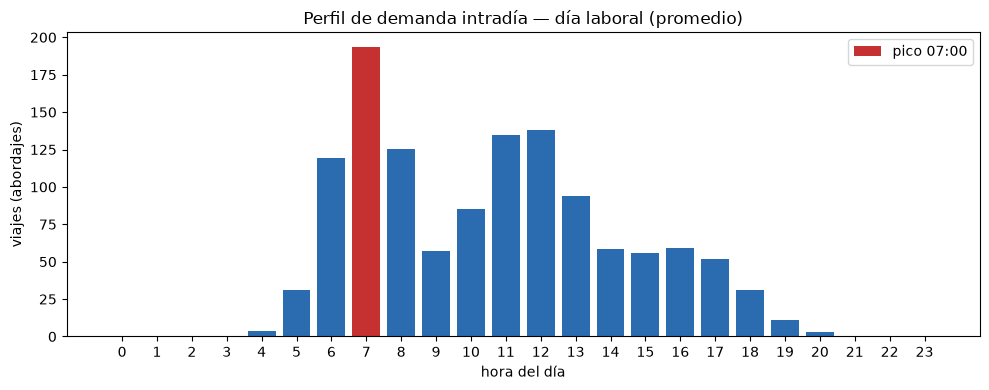

Hora pico: 07:00 con ~194 viajes
Valle (03:00): ~0 viajes  |  razón pico/valle ≈ 194x


In [4]:
# Perfil horario promedio de un día laboral.
dias_lab = [evs for f, evs in eventos_por_dia.items() if baseline.clasificar_dia(f) == "laboral"]
tensores_lab = np.stack([reconstruir_od_por_hora(evs) for evs in dias_lab])   # (D, 24, N, N)
perfil_hora = tensores_lab.sum(axis=(2, 3)).mean(axis=0)                       # viajes/hora promedio

pico = int(np.argmax(perfil_hora))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(24), perfil_hora, color="#2b6cb0")
ax.bar(pico, perfil_hora[pico], color="#c53030", label=f"pico {pico:02d}:00")
ax.set_xlabel("hora del día"); ax.set_ylabel("viajes (abordajes)")
ax.set_title("Perfil de demanda intradía — día laboral (promedio)")
ax.set_xticks(range(24)); ax.legend()
plt.tight_layout(); plt.show()

print(f"Hora pico: {pico:02d}:00 con ~{perfil_hora[pico]:.0f} viajes")
print(f"Valle (03:00): ~{perfil_hora[3]:.0f} viajes  |  razón pico/valle ≈ "
      f"{perfil_hora[pico] / max(perfil_hora[3], 1):.0f}x")

## 3. El promedio diario aplana el pico

Hoy el sistema estima la demanda de cualquier hora como `Mbase_diaria · (ventana/1440)`: un
**prorrateo uniforme**. A escala de 1 h eso es `Mbase_diaria / 24` — la misma cifra a las 03:00
que a las 08:00. La barra roja es lo que el sistema "ve"; las azules, la demanda real.

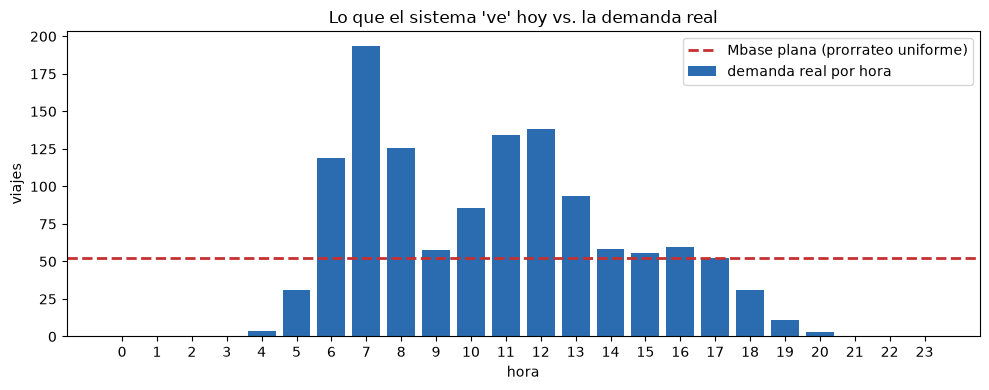

Estimación plana del sistema: 52 viajes/hora (constante).
En el pico 07:00 SUBESTIMA en 73%  -> buses insuficientes -> cola.
En el valle 03:00 SOBRESTIMA fuerte -> buses de más -> viajan vacíos.


In [5]:
mbase_diaria_lab = np.mean([reconstruir_od(evs) for evs in dias_lab], axis=0)
estimacion_plana = mbase_diaria_lab.sum() / 24.0      # lo que ve hoy el sistema, toda hora igual

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(24), perfil_hora, color="#2b6cb0", label="demanda real por hora")
ax.axhline(estimacion_plana, color="#c53030", ls="--", lw=2,
           label="Mbase plana (prorrateo uniforme)")
ax.set_xlabel("hora"); ax.set_ylabel("viajes")
ax.set_title("Lo que el sistema 've' hoy vs. la demanda real")
ax.set_xticks(range(24)); ax.legend()
plt.tight_layout(); plt.show()

sub = 100 * (perfil_hora[pico] - estimacion_plana) / perfil_hora[pico]
print(f"Estimación plana del sistema: {estimacion_plana:.0f} viajes/hora (constante).")
print(f"En el pico {pico:02d}:00 SUBESTIMA en {sub:.0f}%  -> buses insuficientes -> cola.")
print(f"En el valle 03:00 SOBRESTIMA fuerte -> buses de más -> viajan vacíos.")

## 4. Mbase intradía: `tipo_día → (24, N, N)`

Promediar el tensor horario sobre los días de cada tipo. Es el análogo a `baseline.build_baseline`
pero con eje horario: la pieza que reemplazaría a `Mbase[tipo_día]` en el motor.

In [6]:
def build_mbase_intradia(eventos_por_dia):
    acc = defaultdict(list)
    for fecha, evs in eventos_por_dia.items():
        acc[baseline.clasificar_dia(fecha)].append(reconstruir_od_por_hora(evs))
    return {t: np.mean(np.stack(v), axis=0) for t, v in acc.items() if v}

mbase_intradia = build_mbase_intradia(eventos_por_dia)
for t, ten in mbase_intradia.items():
    h_pico = int(ten.sum(axis=(1, 2)).argmax())
    print(f"  {t:8s}: tensor {ten.shape}, {ten.sum():.0f} viajes/día, pico en hora {h_pico:02d}")

  laboral : tensor (24, 45, 45), 1252 viajes/día, pico en hora 07
  sabado  : tensor (24, 45, 45), 803 viajes/día, pico en hora 07
  domingo : tensor (24, 45, 45), 553 viajes/día, pico en hora 07
  feriado : tensor (24, 45, 45), 371 viajes/día, pico en hora 07


## 5. Tabla de despacho precalculada — "el entrenamiento"

Se resuelve el MILP **offline** para cada `(tipo_día, hora)` con la demanda de esa hora. La función
`resolver` reusa la lógica de `engine.optimizer.milp` (reparto OD→servicio sin doble conteo,
factor de capacidad por incidencias, recursos finitos) y permite elegir el objetivo
**suma** (actual) o **minimax** (propuesto), y acotar la flota disponible.

In [7]:
W_UNMET, W_OPER = milp.W_UNMET, milp.W_OPER          # 1.0 y 12.0
CAP_BUS = 160                                         # capacidad por bus (Settings.CAPACIDAD_BUS)
RECURSOS = min(120, 140)                              # min(flota_total, conductores)
MAX_DESP = 20
SERV = [s.codigo for s in topology.SERVICIOS]

def resolver_demanda(demanda, objetivo="suma", recursos=RECURSOS, factor=None):
    '''Resuelve el despacho para una demanda {servicio: viajes}. Devuelve (disp, unmet, obj).'''
    factor = factor or {s: 1.0 for s in SERV}
    solver = pywraplp.Solver.CreateSolver("CBC")
    n = {}
    for s in topology.SERVICIOS:
        for term in topology.terminales_de_servicio(s):
            n[(s.codigo, term)] = solver.IntVar(0, MAX_DESP, f"n_{s.codigo}_{term}")
    unmet = {}
    for s in topology.SERVICIOS:
        unmet[s.codigo] = solver.NumVar(0, solver.infinity(), f"u_{s.codigo}")
        cap_s = solver.Sum([n[(s.codigo, t)] for t in topology.terminales_de_servicio(s)]) \
            * CAP_BUS * factor[s.codigo]
        solver.Add(unmet[s.codigo] >= demanda[s.codigo] - cap_s)
    solver.Add(solver.Sum(list(n.values())) <= recursos)
    if objetivo == "minimax":
        umax = solver.NumVar(0, solver.infinity(), "umax")
        for s in SERV:
            solver.Add(umax >= unmet[s])
        # ×|servicios| para que la presión de cobertura sea comparable a la del objetivo suma.
        solver.Minimize(W_UNMET * umax * len(SERV) + W_OPER * solver.Sum(list(n.values())))
    else:
        solver.Minimize(W_UNMET * solver.Sum(list(unmet.values()))
                        + W_OPER * solver.Sum(list(n.values())))
    solver.Solve()
    disp = {k: int(round(v.solution_value())) for k, v in n.items() if v.solution_value() >= 0.5}
    um = {s: unmet[s].solution_value() for s in SERV}
    return disp, um, solver.Objective().Value()

def resolver(m_hora, objetivo="suma", recursos=RECURSOS, incidencias=None):
    demanda = milp.asignar_demanda_a_servicios(m_hora)
    factor = milp.factor_capacidad_por_servicio(incidencias or [])
    return resolver_demanda(demanda, objetivo, recursos, factor)

In [8]:
t0 = time.perf_counter()
tabla = {}                                            # (tipo_día, hora) -> disp
for tipo, ten in mbase_intradia.items():
    for h in range(24):
        disp, _, _ = resolver(ten[h], objetivo="minimax")
        tabla[(tipo, h)] = disp
dt = time.perf_counter() - t0

print(f"Tabla precalculada: {len(tabla)} escenarios (tipo_día × hora) en {dt:.2f} s OFFLINE.")
print(f"Costo medio: {1000 * dt / len(tabla):.1f} ms/escenario. En RUNTIME es un lookup O(1).\n")
print("Laboral hora pico", pico, "->", tabla[("laboral", pico)])
print("Laboral valle 03  ->", tabla[("laboral", 3)] or "{} (sin despachos: no hay demanda)")

Tabla precalculada: 96 escenarios (tipo_día × hora) en 0.24 s OFFLINE.
Costo medio: 2.5 ms/escenario. En RUNTIME es un lookup O(1).

Laboral hora pico 7 -> {('REG', 'Terminal Matellini'): 2, ('EXP_A', 'Terminal Matellini'): 1, ('EXP_B', 'Terminal Matellini'): 1}
Laboral valle 03  -> {} (sin despachos: no hay demanda)


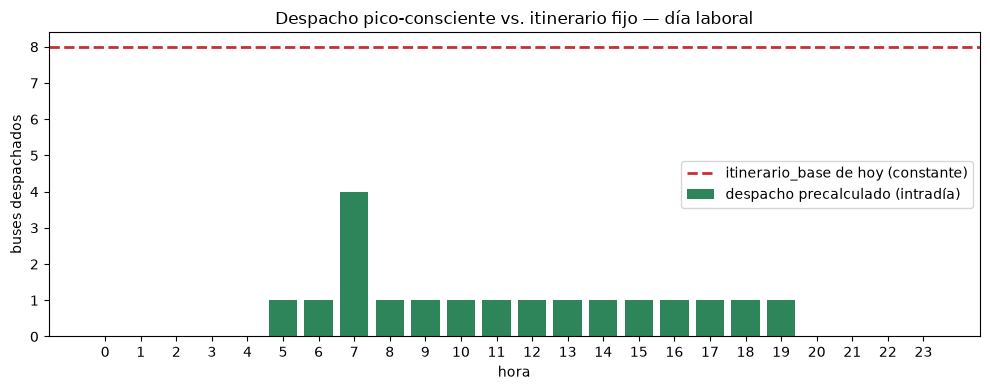

In [9]:
# El despacho precalculado SIGUE el pico; hoy el itinerario_base despacha lo mismo a toda hora.
buses_hora = [sum(tabla[("laboral", h)].values()) for h in range(24)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(24), buses_hora, color="#2f855a", label="despacho precalculado (intradía)")
ax.axhline(2 * len(topology.TERMINALES), color="#c53030", ls="--", lw=2,
           label="itinerario_base de hoy (constante)")
ax.set_xlabel("hora"); ax.set_ylabel("buses despachados")
ax.set_title("Despacho pico-consciente vs. itinerario fijo — día laboral")
ax.set_xticks(range(24)); ax.legend()
plt.tight_layout(); plt.show()

## 6. Objetivo minimax vs. suma

El objetivo **suma** minimiza la demanda total no servida; puede dejar una ruta con cola enorme si
es "barato" en agregado. El **minimax** minimiza la *peor* cola, repartiendo cobertura.

La diferencia aparece **cuando la flota es el cuello de botella** (pico severo) y la demanda entre
rutas es comparable. Lo verificamos en dos escenarios.

In [10]:
# (a) Demanda REAL del pico laboral, con flota suficiente.
m_pico = mbase_intradia["laboral"][pico]
dem_pico = milp.asignar_demanda_a_servicios(m_pico)
print("Demanda por servicio en el pico:", {k: round(v) for k, v in dem_pico.items()})
print("(La OD sintética es REG-dominada: casi toda la demanda cae en el Regular.)\n")

_, um_s, _ = resolver(m_pico, "suma")
_, um_m, _ = resolver(m_pico, "minimax")
print(f"Peor cola con flota suficiente:  suma={max(um_s.values()):.0f}  "
      f"minimax={max(um_m.values()):.0f}")
print("El objetivo suma deja sin servir la cola chica de un expreso (no 'paga' un bus por")
print("pocos pasajeros); el minimax sí la cubre, porque es la peor cola relativa.")

Demanda por servicio en el pico: {'REG': 173, 'EXP_A': 11, 'EXP_B': 10}
(La OD sintética es REG-dominada: casi toda la demanda cae en el Regular.)

Peor cola con flota suficiente:  suma=11  minimax=0
El objetivo suma deja sin servir la cola chica de un expreso (no 'paga' un bus por
pocos pasajeros); el minimax sí la cubre, porque es la peor cola relativa.


In [11]:
# (b) Escenario ilustrativo con demanda COMPARABLE entre rutas y flota escasa
#     (representa el corredor real, donde los expresos cargan volúmenes parecidos al regular).
dem_balance = {"REG": 500, "EXP_A": 480, "EXP_B": 460}
FLOTA_ESCASA = 6   # 6 buses × 160 = 960 de capacidad para 1440 de demanda -> hay que racionar

disp_s, um_s, _ = resolver_demanda(dem_balance, "suma", recursos=FLOTA_ESCASA)
disp_m, um_m, _ = resolver_demanda(dem_balance, "minimax", recursos=FLOTA_ESCASA)

def buses_por_serv(disp):
    return {s: sum(b for (sv, t), b in disp.items() if sv == s) for s in SERV}

tabla_cmp = pd.DataFrame({
    "demanda": dem_balance,
    "buses_SUMA": buses_por_serv(disp_s),     "cola_SUMA": {s: round(um_s[s]) for s in SERV},
    "buses_MINIMAX": buses_por_serv(disp_m),  "cola_MINIMAX": {s: round(um_m[s]) for s in SERV},
})
print(tabla_cmp, "\n")
print(f"Peor cola  SUMA = {max(um_s.values()):.0f}   MINIMAX = {max(um_m.values()):.0f} "
      f"(misma flota = {FLOTA_ESCASA} buses)")
print("-> el objetivo suma puede amontonar buses en una ruta y dejar otra colapsada;")
print("   el minimax reparte y baja la peor cola.")

       demanda  buses_SUMA  cola_SUMA  buses_MINIMAX  cola_MINIMAX
REG        500           1        340              2           180
EXP_A      480           3          0              2           160
EXP_B      460           2        140              2           140 

Peor cola  SUMA = 340   MINIMAX = 180 (misma flota = 6 buses)
-> el objetivo suma puede amontonar buses en una ruta y dejar otra colapsada;
   el minimax reparte y baja la peor cola.


## 7. Cuantificación del impacto: hoy (plana + suma) vs. propuesta (intradía + minimax)

Evaluación honesta: ambos planes se miden contra la **demanda real por hora**. El plan de "hoy" se
dimensiona con la estimación plana (igual a toda hora); el plan "propuesta" usa la demanda intradía.
La cola realizada de un servicio es `max(0, demanda_real − buses·CAP_BUS)`.

In [12]:
def colas_contra_real(m_real, disp):
    dem = milp.asignar_demanda_a_servicios(m_real)
    out = {}
    for s in topology.SERVICIOS:
        buses = sum(b for (sv, t), b in disp.items() if sv == s.codigo)
        out[s.codigo] = max(0.0, dem[s.codigo] - buses * CAP_BUS)
    return out

mbase_plana_hora = mbase_diaria_lab / 24.0                       # lo que ve hoy el sistema
disp_hoy, _, _ = resolver(mbase_plana_hora, "suma")             # plan fijo de hoy (misma toda hora)

filas = []
for h in range(5, 23):                                          # horas de operación
    real = mbase_intradia["laboral"][h]
    disp_prop = tabla[("laboral", h)]                          # plan precalculado intradía+minimax
    cola_hoy = max(colas_contra_real(real, disp_hoy).values())
    cola_prop = max(colas_contra_real(real, disp_prop).values())
    filas.append({
        "hora": h,
        "demanda_real": round(real.sum()),
        "buses_hoy": sum(disp_hoy.values()),
        "peor_cola_hoy": round(cola_hoy),
        "buses_prop": sum(disp_prop.values()),
        "peor_cola_prop": round(cola_prop),
    })
impacto = pd.DataFrame(filas).set_index("hora")
print(impacto)

tot_hoy = impacto["peor_cola_hoy"].sum()
tot_prop = impacto["peor_cola_prop"].sum()
print(f"\nPasajeros-hora en la peor cola:  hoy={tot_hoy:.0f}   propuesta={tot_prop:.0f}   "
      f"reducción={100 * (tot_hoy - tot_prop) / max(tot_hoy, 1):.0f}%")
print(f"En la HORA PICO {pico:02d}:00 la peor cola cae de "
      f"{impacto.loc[pico, 'peor_cola_hoy']:.0f} a {impacto.loc[pico, 'peor_cola_prop']:.0f}: "
      f"el plan plano la provoca, el intradía la elimina.")
print("(Las colas absolutas son modestas porque la escala sintética es chica y CAP_BUS=160 es "
      "grande frente a la demanda horaria; lo estructural es el patrón, no la magnitud.)")

      demanda_real  buses_hoy  peor_cola_hoy  buses_prop  peor_cola_prop
hora                                                                    
5               31          1              1           1               1
6              119          1              6           1               6
7              194          1             13           4               0
8              125          1              7           1               7
9               57          1              3           1               3
10              86          1              5           1               5
11             134          1              7           1               7
12             138          1              7           1               7
13              94          1              5           1               5
14              59          1              3           1               3
15              56          1              3           1               3
16              59          1              3       

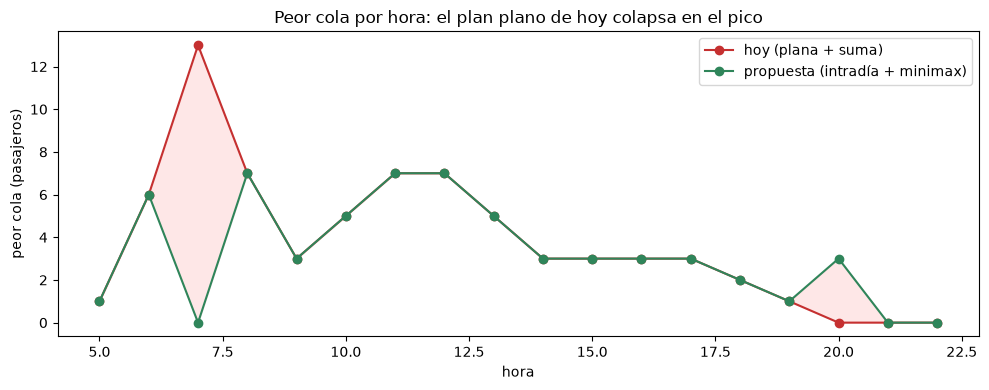

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(impacto.index, impacto["peor_cola_hoy"], "o-", color="#c53030", label="hoy (plana + suma)")
ax.plot(impacto.index, impacto["peor_cola_prop"], "o-", color="#2f855a",
        label="propuesta (intradía + minimax)")
ax.fill_between(impacto.index, impacto["peor_cola_prop"], impacto["peor_cola_hoy"],
                color="#fed7d7", alpha=0.6)
ax.set_xlabel("hora"); ax.set_ylabel("peor cola (pasajeros)")
ax.set_title("Peor cola por hora: el plan plano de hoy colapsa en el pico")
ax.legend()
plt.tight_layout(); plt.show()

## 8. Propuesta de integración al motor (trabajo siguiente)

Validado el concepto, así se plegaría a `engine/`+`app/` (fuera de esta pasada de exploración):

1. **`engine/demand/baseline.py` + `historico.py`** — añadir construcción por hora:
   `Mbase[tipo_día] → Mbase[tipo_día][hora]` (`build_baseline_intradia`, tensor `24×N×N`).
   Mantener la diaria para compatibilidad/degradación.
2. **`scripts/seed_dispatch_table.py`** (nuevo) — precalcular la tabla `(tipo_día, hora) → plan`
   resolviendo el MILP offline y cacheándola en Redis (clave `dispatch:tabla:{tipo}:{hora}`).
   Es la versión "entrenamiento" del actual `seed_baseline.py`.
3. **`app/core/scheduler.py`** — en el caso base (gating no dispara), en vez de
   `milp.itinerario_base`, hacer **lookup O(1)** del plan precalculado para la hora actual.
   El MILP online se reserva para desviaciones reales (`‖ΔM‖₂ > ε`) e incidencias.
4. **`engine/optimizer/milp.py`** — reformular `resolver_despacho` al objetivo **minimax**
   (`U_max ≥ unmet[s]`), que es el prototipo de la sección 5–6.
5. **ΔM contra el baseline horario** — el residuo de Kalman se compara contra
   `Mbase_intradia[tipo_día][hora_actual]` en vez del prorrateo uniforme de `escalar_a_ventana`.

### Hallazgos / caveats de los datos
- **El generador sintético tiene esencialmente un solo pico de mañana** (`hora ~ N(7.5, 1)` con
  viajes de retorno dispersos). El perfil 24 h sale casi unimodal. Para ejercitar de verdad el
  modelo intradía conviene darle un **pico de tarde** (movilidad bimodal) a
  `engine/trip_chaining/synthetic.py`.
- **La OD sintética es REG-dominada**: casi toda la demanda cae en el servicio Regular porque los
  expresos cubren pocas estaciones, así que minimax≈suma sobre estos datos (sección 6a). El minimax
  rinde cuando las rutas cargan volúmenes comparables (sección 6b) — el caso real del corredor.
- El mayor lever inmediato es la **granularidad intradía** (sección 7): elimina el doble defecto de
  hoy —buses insuficientes en el pico y buses vacíos en el valle—.